This notebook cleans vacancies data and saves it in csv format.

In [1]:
import pandas as pd
import json

with open('../data/vacancies.json', 'r') as file:
    vacancies = json.load(file)

df = pd.DataFrame.from_records(vacancies) 
df.head()

,id,premium,billing_type,relations,name,insider_interview,response_letter_required,area,salary,type,...,apply_alternate_url,has_test,test,alternate_url,working_days,working_time_intervals,working_time_modes,accept_temporary,languages,approved
0,95985328,False,"{'id': 'standard', 'name': 'Стандарт'}",[],Подсобный рабочий,None,False,"{'id': '1002', 'name': 'Минск', 'url': 'https:...",None,"{'id': 'open', 'name': 'Открытая'}",...,https://hh.ru/applicant/vacancy_response?vacan...,False,None,https://hh.ru/vacancy/95985328,[],[],[],False,[],True
1,94218916,False,"{'id': 'standard', 'name': 'Стандарт'}",[],Старший контролер-кассир,None,False,"{'id': '2352', 'name': 'Шклов', 'url': 'https:...","{'from': 1100, 'to': 1250, 'currency': 'BYR', ...","{'id': 'open', 'name': 'Открытая'}",...,https://hh.ru/applicant/vacancy_response?vacan...,False,None,https://hh.ru/vacancy/94218916,[],[],[],False,[],True
2,97651501,False,"{'id': 'standard', 'name': 'Стандарт'}",[],Каменщик,None,False,"{'id': '2264', 'name': 'Орша', 'url': 'https:/...","{'from': 3000, 'to': 6000, 'currency': 'BYR', ...","{'id': 'open', 'name': 'Открытая'}",...,https://hh.ru/applicant/vacancy_response?vacan...,False,None,https://hh.ru/vacancy/97651501,[],[],[],False,[],True
3,98133457,False,"{'id': 'standard', 'name': 'Стандарт'}",[],"Водитель категории В,С в г. Минск",None,False,"{'id': '1002', 'name': 'Минск', 'url': 'https:...","{'from': 2100, 'to': None, 'currency': 'BYR', ...","{'id': 'open', 'name': 'Открытая'}",...,https://hh.ru/applicant/vacancy_response?vacan...,False,None,https://hh.ru/vacancy/98133457,[],[],[],False,[],True
4,98224341,False,"{'id': 'standard', 'name': 'Стандарт'}",[],Продавец,None,False,"{'id': '1006', 'name': 'Гродно', 'url': 'https...","{'from': 1000, 'to': None, 'currency': 'BYR', ...","{'id': 'open', 'name': 'Открытая'}",...,https://hh.ru/applicant/vacancy_response?vacan...,False,None,https://hh.ru/vacancy/98224341,[],[],[],False,[],True


Filtering from unnecessary rows.

In [16]:
print(f'Number of all rows: {len(df)}')

df_approved = df[df['approved']]
print(f'Number of rows with approved vacancies: {len(df_approved)}')

df_salary_not_none = df_approved.dropna(subset=['salary'])
print(f'Number of rows with non-none salary: {len(df_salary_not_none)}')

df_with_salary_from = df_salary_not_none[df_salary_not_none['salary'].map(lambda x: isinstance(x, dict)) & 
                                         df_salary_not_none['salary'].map(lambda x: x['from'] is not None)]
print(f'Number of rows with non-none lower bound of salary: {len(df_with_salary_from)}')

df_with_salary_to = df_salary_not_none[df_salary_not_none['salary'].map(lambda x: isinstance(x, dict)) & 
                                         df_salary_not_none['salary'].map(lambda x: x['to'] is not None)]
print(f'Number of rows with non-none upper bound of salary: {len(df_with_salary_to)}')

df_with_salary_from_and_to = df_with_salary_from[df_with_salary_from['salary'].map(lambda x: x['to'] is not None)]
print(f'Number of rows with non-none lower and upper bounds of salary: {len(df_with_salary_from_and_to)}')

Number of all rows: 29692
Number of rows with approved vacancies: 29690
Number of rows with non-none salary: 24040
Number of rows with non-none lower bound of salary: 22973
Number of rows with non-none upper bound of salary: 11950
Number of rows with non-none lower and upper bounds of salary: 10883


We will predict lower bound of salary with BYR currency.

In [3]:
df_with_salary_from_byr = df_with_salary_from[df_with_salary_from['salary'].map(lambda x: x['currency'] == 'BYR')]
print(f'Number of rows with BYR currency: {len(df_with_salary_from_byr)}')

Number of rows with BYR currency: 22287


Filtering from unnecessary columns.

In [4]:
from html2text import html2text

print(f'Number of all columns: {df.shape[1]}')
REQUIRED_COLUMNS = ['id',
                    'billing_type',
                    'name',
                    'response_letter_required',
                    'area',
                    'salary',
                    'allow_messages',
                    'experience',
                    'schedule',
                    'employment',
                    'description',
                    'accept_handicapped',
                    'accept_kids',
                    'driver_license_types',
                    'accept_incomplete_resumes',
                    'employer',
                    'has_test',
                    'accept_temporary']
df_with_salary_from_byr = df_with_salary_from_byr[REQUIRED_COLUMNS]
print(f'Number of required_columns: {df_with_salary_from_byr.shape[1]}')

df_with_salary_from_byr['salary'] = df_with_salary_from_byr['salary'].apply(lambda x: x['from'])
df_with_salary_from_byr['description'] = df_with_salary_from_byr['description'].apply(lambda x: html2text(x))
df_with_salary_from_byr['billing_type'] = df_with_salary_from_byr['billing_type'].apply(lambda x: x['name'])
df_with_salary_from_byr['area'] = df_with_salary_from_byr['area'].apply(lambda x: x['name'])
df_with_salary_from_byr['experience'] = df_with_salary_from_byr['experience'].apply(lambda x: x['name'])
df_with_salary_from_byr['schedule'] = df_with_salary_from_byr['schedule'].apply(lambda x: x['name'])
df_with_salary_from_byr['employment'] = df_with_salary_from_byr['employment'].apply(lambda x: x['name'])
df_with_salary_from_byr['employer'] = df_with_salary_from_byr['employer'].apply(lambda x: x['name'])
df_with_salary_from_byr['driver_license_types'] = df_with_salary_from_byr['driver_license_types'].apply(
    lambda x: ','.join(sorted([category['id'] for category in x])) if len(x) > 0 else 'None'
)

df_with_salary_from_byr.head()

Number of all columns: 48
Number of required_columns: 18


,id,billing_type,name,response_letter_required,area,salary,allow_messages,experience,schedule,employment,description,accept_handicapped,accept_kids,driver_license_types,accept_incomplete_resumes,employer,has_test,accept_temporary
1,94218916,Стандарт,Старший контролер-кассир,False,Шклов,1100,True,Нет опыта,Полный день,Полная занятость,"**Сеть магазинов ""Копеечка"", ""Маяк"", ""Доброном...",False,False,None,False,Доброном,False,False
2,97651501,Стандарт,Каменщик,False,Орша,3000,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n**все подробности по телеф...,False,False,None,True,Тримифинжстрой,False,False
3,98133457,Стандарт,"Водитель категории В,С в г. Минск",False,Минск,2100,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n * перевозка продуктов пи...,False,False,"B,C",False,АйсЛогистик,False,False
4,98224341,Стандарт,Продавец,False,Гродно,1000,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n * Консультация покупател...,False,False,None,False,Бакалея Гродно,False,False
5,98449416,Стандарт,Инженер ПТО,False,Минск,3500,True,От 1 года до 3 лет,Полный день,Полная занятость,* М-29\n * Акты выполненных работ\n * Граф...,False,False,None,False,Белспецстройтехника,False,True


The distribution is fat-tailed on the right side, which is inconvenient for MSE minimization, therefore we will use log-target.

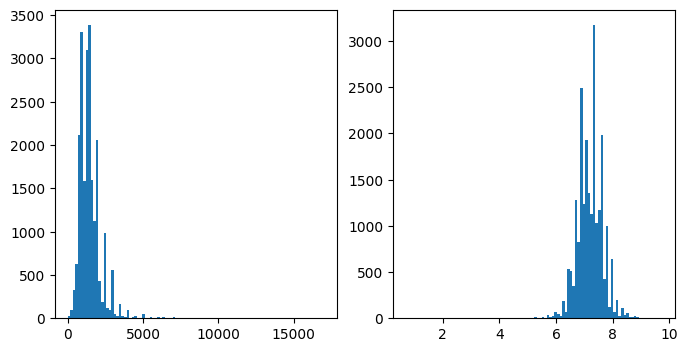

In [5]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


df_with_salary_from_byr['log1p_salary'] = np.log1p(df_with_salary_from_byr['salary']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(df_with_salary_from_byr['salary'], bins=100)

plt.subplot(1, 2, 2)
plt.hist(df_with_salary_from_byr['log1p_salary'], bins=100)
plt.show()

In [6]:
df_with_salary_from_byr.to_csv('../data/clean_vacancies.csv')